# Oracle Guided Agent — Fact Usage Analysis

Analyzes how many facts from the preprocessed fact graphs are actually used vs skipped during oracle-guided evaluation runs.

**Data Sources:**
- **Fact graphs**: `{PREPROCESS_DIR}/{instance_id}/stage2_facts.json`
- **Oracle guided logs**: `{LOGS_DIR}/{instance_id}.jsonl`

In [1]:
# ── Configuration ──
# Change these paths to point to your data

PREPROCESS_DIR = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/preprocess/swegym_v6_phase1"
LOGS_DIR = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/oracle_guided_logs"

In [2]:
import json
import os
import glob
from collections import defaultdict, Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    print("seaborn not installed — using matplotlib defaults")

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 200)

## 1. Load Fact Graphs

In [3]:
# Load all stage2_facts.json files
fact_graphs: dict[str, list[dict]] = {}  # instance_id -> nodes list

for entry in sorted(os.listdir(PREPROCESS_DIR)):
    facts_path = os.path.join(PREPROCESS_DIR, entry, "stage2_facts.json")
    if not os.path.isfile(facts_path):
        continue
    with open(facts_path, "r") as f:
        data = json.load(f)
    instance_id = data.get("instance_id", entry)
    fact_graphs[instance_id] = data["nodes"]

print(f"Loaded fact graphs for {len(fact_graphs)} instances")

# Quick summary of node types across all graphs
all_node_types = Counter()
for nodes in fact_graphs.values():
    for node in nodes:
        all_node_types[node["node_type"]] += 1

print(f"\nNode type distribution across all graphs:")
for nt, count in all_node_types.most_common():
    print(f"  {nt}: {count}")

Loaded fact graphs for 1629 instances

Node type distribution across all graphs:
  fact: 26715
  code_edit: 6632
  validation: 5058
  reproduce_script: 1868
  issue_analysis: 1627
  fix_plan: 1619
  dynamic: 58
  static: 24


## 2. Load Oracle Guided Logs

In [4]:
# Parse oracle guided log files
# For each instance, extract:
#   - last fact_usage_summary (final state)
#   - skipped_facts from exploration_exit_approved / forced_stage_transition events
#   - total steps (max step_index)

log_data: dict[str, dict] = {}  # instance_id -> parsed log summary

for fname in sorted(os.listdir(LOGS_DIR)):
    if not fname.endswith(".jsonl"):
        continue
    instance_id = fname.replace(".jsonl", "")
    fpath = os.path.join(LOGS_DIR, fname)

    last_usage_summary = None
    skipped_facts: list[str] = []
    max_step = 0
    total_planner_decisions = 0
    total_stage_gate_blocks = 0
    stages_seen: set[str] = set()

    with open(fpath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue

            step = entry.get("step_index", 0)
            if step > max_step:
                max_step = step

            event = entry.get("event", "")

            if event == "fact_usage_summary":
                last_usage_summary = entry

            elif event in ("exploration_exit_approved", "forced_stage_transition"):
                for fid in entry.get("skipped_facts", []):
                    if fid not in skipped_facts:
                        skipped_facts.append(fid)

            elif event == "oracle_planner_decision":
                total_planner_decisions += 1
                stage = entry.get("stage", "")
                if stage:
                    stages_seen.add(stage)

            elif event == "stage_gate_block":
                total_stage_gate_blocks += 1

    if last_usage_summary is None:
        # No usage summary = log may be empty or malformed, skip
        continue

    log_data[instance_id] = {
        "last_usage_summary": last_usage_summary,
        "skipped_facts": skipped_facts,
        "max_step": max_step,
        "total_planner_decisions": total_planner_decisions,
        "total_stage_gate_blocks": total_stage_gate_blocks,
        "stages_seen": sorted(stages_seen),
    }

print(f"Parsed oracle guided logs for {len(log_data)} instances")
print(f"  (out of {len(os.listdir(LOGS_DIR))} log files in the directory)")

Parsed oracle guided logs for 527 instances
  (out of 527 log files in the directory)


## 3. Join Datasets & Compute Per-Instance Metrics

In [5]:
# Only instances that have BOTH a fact graph and a log file
common_ids = sorted(set(fact_graphs.keys()) & set(log_data.keys()))
print(f"Finished instances (have both fact graph + log): {len(common_ids)}")
print(f"  Fact graphs only (no log):  {len(set(fact_graphs.keys()) - set(log_data.keys()))}")
print(f"  Logs only (no fact graph):  {len(set(log_data.keys()) - set(fact_graphs.keys()))}")

Finished instances (have both fact graph + log): 525
  Fact graphs only (no log):  1104
  Logs only (no fact graph):  2


In [6]:
rows = []

for iid in common_ids:
    nodes = fact_graphs[iid]
    ld = log_data[iid]
    summary = ld["last_usage_summary"]

    # From the fact graph: count nodes by type
    fact_node_ids = [n["id"] for n in nodes if n["node_type"] == "fact"]
    artifact_node_ids = [n["id"] for n in nodes if n["node_type"] != "fact"]
    all_node_ids = [n["id"] for n in nodes]

    # From the log: which nodes were marked "used" (includes auto-marked)
    used_ids = set(summary.get("used_ids", []))

    # Facts auto-marked during stage transitions (exploration_exit_approved
    # or forced_stage_transition) should NOT count as genuinely used.
    transition_skipped = set(ld["skipped_facts"])

    # Genuinely used = in used_ids AND NOT auto-marked by stage transition
    facts_used_ids = [
        fid for fid in fact_node_ids
        if fid in used_ids and fid not in transition_skipped
    ]
    artifacts_used_ids = [fid for fid in artifact_node_ids if fid in used_ids]

    # Unused = not genuinely used (skipped, blocked, unreached, auto-marked)
    genuinely_used = set(facts_used_ids)
    facts_unused_ids = [fid for fid in fact_node_ids if fid not in genuinely_used]

    total_facts = len(fact_node_ids)
    facts_used = len(facts_used_ids)
    facts_unused = len(facts_unused_ids)

    total_artifacts = len(artifact_node_ids)
    artifacts_used = len(artifacts_used_ids)

    usage_rate = facts_used / total_facts if total_facts > 0 else 0.0
    artifact_usage_rate = artifacts_used / total_artifacts if total_artifacts > 0 else 0.0

    rows.append({
        "instance_id": iid,
        "total_nodes": len(all_node_ids),
        "total_facts": total_facts,
        "facts_used": facts_used,
        "facts_unused": facts_unused,
        "fact_usage_rate": usage_rate,
        "total_artifacts": total_artifacts,
        "artifacts_used": artifacts_used,
        "artifact_usage_rate": artifact_usage_rate,
        "total_steps": ld["max_step"],
        "planner_decisions": ld["total_planner_decisions"],
        "stage_gate_blocks": ld["total_stage_gate_blocks"],
        "stages_reached": ", ".join(ld["stages_seen"]),
        "used_fact_ids": sorted(facts_used_ids),
        "unused_fact_ids": sorted(facts_unused_ids),
    })

df = pd.DataFrame(rows)
print(f"Built metrics DataFrame: {len(df)} instances")
df.head(3)

Built metrics DataFrame: 525 instances


,instance_id,total_nodes,total_facts,facts_used,facts_unused,fact_usage_rate,total_artifacts,artifacts_used,artifact_usage_rate,total_steps,planner_decisions,stage_gate_blocks,stages_reached,used_fact_ids,unused_fact_ids
0,conan-io__conan-10959,18,11,11,0,1.0,7,4,0.571429,18,12,3,"exploration, implementation_verification, reproduction","[f1, f14, f15, f16, f2, f3, f4, f5, f7, f8, f9]",[]
1,conan-io__conan-10975,16,9,9,0,1.0,7,4,0.571429,70,74,8,"analysis_planning, exploration, implementation_verification, reproduction","[f1, f11, f12, f13, f14, f2, f3, f5, f6]",[]
2,conan-io__conan-11560,18,10,7,3,0.7,8,4,0.500000,21,24,4,"exploration, implementation_verification, reproduction","[f1, f14, f2, f3, f4, f5, f6]","[f15, f16, f7]"


## 4b. Instance Filter

Configure filtering rules to keep only "good" instances. Toggle each rule with `True`/`False`.

Rules:
1. **repro used** — `reproduce_script` artifact was used
2. **analysis used** — `issue_analysis` artifact was used
3. **plan used** — `fix_plan` artifact was used
4. **edit & valid usage rate > threshold** — `code_edit` + `validation` used / total
5. **fact usage rate > threshold** — genuinely used facts / total facts


In [7]:
# ── Per-artifact-type usage enrichment ──
# Compute, for each instance, which artifact types were used and
# the combined edit+validation usage rate.

ARTIFACT_TYPE_BY_PREFIX = {
    "reproduce_script": "repro_used",
    "issue_analysis":   "analysis_used",
    "fix_plan":         "plan_used",
}

enrich_rows = []
for iid in common_ids:
    nodes = fact_graphs[iid]
    used_ids = set(log_data[iid]["last_usage_summary"].get("used_ids", []))

    repro_used = analysis_used = plan_used = False
    edit_total = edit_used = 0
    valid_total = valid_used = 0

    for node in nodes:
        nt = node["node_type"]
        nid = node["id"]
        is_used = nid in used_ids
        if nt == "reproduce_script":
            repro_used = repro_used or is_used
        elif nt == "issue_analysis":
            analysis_used = analysis_used or is_used
        elif nt == "fix_plan":
            plan_used = plan_used or is_used
        elif nt == "code_edit":
            edit_total += 1
            edit_used += int(is_used)
        elif nt == "validation":
            valid_total += 1
            valid_used += int(is_used)

    ev_total = edit_total + valid_total
    ev_used = edit_used + valid_used
    ev_rate = ev_used / ev_total if ev_total > 0 else float("nan")

    enrich_rows.append({
        "instance_id": iid,
        "repro_used": repro_used,
        "analysis_used": analysis_used,
        "plan_used": plan_used,
        "edit_total": edit_total,
        "edit_used": edit_used,
        "valid_total": valid_total,
        "valid_used": valid_used,
        "edit_valid_total": ev_total,
        "edit_valid_used": ev_used,
        "edit_valid_usage_rate": ev_rate,
    })

df_enrich = pd.DataFrame(enrich_rows)
df = df.merge(df_enrich, on="instance_id", how="left")
print(f"Enriched df with per-artifact usage columns: {list(df_enrich.columns[1:])}")


Enriched df with per-artifact usage columns: ['repro_used', 'analysis_used', 'plan_used', 'edit_total', 'edit_used', 'valid_total', 'valid_used', 'edit_valid_total', 'edit_valid_used', 'edit_valid_usage_rate']


In [14]:
# ── Flexible filter ──
# Build any boolean expression over the enriched columns of `df`.
# A "rule" is either:
#   - a (name, callable) pair: callable(df) -> boolean Series
#   - a nested dict: {"any": [rule, rule, ...]} or {"all": [rule, rule, ...]} or {"not": rule}
#
# The top-level FILTER_RULES is combined with AND by default (keep rows that
# satisfy every entry). Use {"any": [...]} inside if you want OR.
#
# Examples:
#   - Keep only if repro + analysis + plan used AND fact_rate > 50%:
#       FILTER_RULES = [
#           ("repro_used",    lambda d: d["repro_used"].fillna(False)),
#           ("analysis_used", lambda d: d["analysis_used"].fillna(False)),
#           ("plan_used",     lambda d: d["plan_used"].fillna(False)),
#           ("fact>50%",      lambda d: d["fact_usage_rate"] > 0.5),
#       ]
#
#   - EXCLUDE only when BOTH edit_valid<50% AND fact<50%
#     (equivalent to: keep if edit_valid>=50% OR fact>=50%):
#       FILTER_RULES = [
#           {"any": [
#               ("edit_valid>=50%", lambda d: d["edit_valid_usage_rate"].fillna(0) >= 0.5),
#               ("fact>=50%",       lambda d: d["fact_usage_rate"] >= 0.5),
#           ]},
#       ]


# ▶ EDIT THIS to change the filter ◀
FILTER_RULES: list = [
    {"any": [
        ("edit_valid>=50%", lambda d: d["edit_valid_usage_rate"].fillna(0) >= 0.7),
        ("fact>=50%",       lambda d: d["fact_usage_rate"] >= 0.7),
    ]},
]


def _eval_rule(rule, d: pd.DataFrame) -> tuple[str, pd.Series]:
    """Evaluate a single rule spec into (label, boolean Series)."""
    if isinstance(rule, tuple) and len(rule) == 2 and callable(rule[1]):
        name, fn = rule
        return name, fn(d).fillna(False).astype(bool)
    if isinstance(rule, dict):
        if "all" in rule:
            parts = [_eval_rule(r, d) for r in rule["all"]]
            mask = pd.Series(True, index=d.index)
            for _, m in parts:
                mask &= m
            return "(" + " & ".join(n for n, _ in parts) + ")", mask
        if "any" in rule:
            parts = [_eval_rule(r, d) for r in rule["any"]]
            mask = pd.Series(False, index=d.index)
            for _, m in parts:
                mask |= m
            return "(" + " | ".join(n for n, _ in parts) + ")", mask
        if "not" in rule:
            n, m = _eval_rule(rule["not"], d)
            return f"not({n})", ~m
    raise ValueError(f"Unrecognized rule spec: {rule!r}")


def apply_filter_rules(d: pd.DataFrame, rules: list) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Apply rules (top-level AND). Returns (df_kept, per-rule bool DataFrame)."""
    reasons = pd.DataFrame({"instance_id": d["instance_id"]})
    combined = pd.Series(True, index=d.index)
    for rule in rules:
        name, mask = _eval_rule(rule, d)
        reasons[name] = mask.values
        combined &= mask.values
    reasons["_kept"] = combined.values
    return d[combined.values].reset_index(drop=True), reasons


df_filtered, filter_reasons = apply_filter_rules(df, FILTER_RULES)

total = len(df)
kept = len(df_filtered)
print(f"Kept {kept} / {total} instances ({kept / total:.1%})")
print()
print("── Per-rule pass counts (top-level, combined with AND) ──")
for col in filter_reasons.columns:
    if col in ("instance_id", "_kept"):
        continue
    passed = int(filter_reasons[col].sum())
    print(f"  {col:50s}  {passed:5d} / {total}  ({passed / total:.1%})")


Kept 452 / 525 instances (86.1%)

── Per-rule pass counts (top-level, combined with AND) ──
  (edit_valid>=50% | fact>=50%)                         452 / 525  (86.1%)


In [15]:
# ── Preview filtered instances ──
# Attach per-instance lists of unused edits / validations / facts.

_unused_rows = []
for iid in df_filtered["instance_id"]:
    nodes = fact_graphs[iid]
    used_ids = set(log_data[iid]["last_usage_summary"].get("used_ids", []))
    transition_skipped = set(log_data[iid]["skipped_facts"])

    unused_edits = [n["id"] for n in nodes
                    if n["node_type"] == "code_edit" and n["id"] not in used_ids]
    unused_valids = [n["id"] for n in nodes
                     if n["node_type"] == "validation" and n["id"] not in used_ids]
    unused_facts = [n["id"] for n in nodes
                    if n["node_type"] == "fact"
                    and (n["id"] not in used_ids or n["id"] in transition_skipped)]

    _unused_rows.append({
        "instance_id": iid,
        "unused_edits": unused_edits,
        "unused_valids": unused_valids,
        "unused_facts": unused_facts,
    })

df_filtered_preview = df_filtered.merge(
    pd.DataFrame(_unused_rows), on="instance_id", how="left"
)

preview_cols = [
    "instance_id", "repro_used", "analysis_used", "plan_used",
    "edit_valid_used", "edit_valid_total", "edit_valid_usage_rate",
    "unused_edits", "unused_valids",
    "facts_used", "total_facts", "fact_usage_rate", "unused_facts",
    "total_steps",
]
df_filtered_preview[preview_cols].style.format({
    "fact_usage_rate": "{:.1%}",
    "edit_valid_usage_rate": "{:.1%}",
})


,instance_id,repro_used,analysis_used,plan_used,edit_valid_used,edit_valid_total,edit_valid_usage_rate,unused_edits,unused_valids,facts_used,total_facts,fact_usage_rate,unused_facts,total_steps
0,conan-io__conan-10959,True,True,True,1,4,25.0%,[],"['val1', 'val2', 'val3']",11,11,100.0%,[],18
1,conan-io__conan-10975,True,True,True,1,4,25.0%,"['edit1', 'edit2']",['val2'],9,9,100.0%,[],70
2,conan-io__conan-11560,True,True,True,1,5,20.0%,['edit2'],"['val1', 'val2', 'val3']",7,10,70.0%,"['f7', 'f15', 'f16']",21
3,conan-io__conan-12397,True,True,True,3,3,100.0%,[],[],10,10,100.0%,[],24
4,conan-io__conan-12695,True,True,True,5,5,100.0%,[],[],18,18,100.0%,[],82
5,conan-io__conan-12762,True,True,True,2,5,40.0%,['edit2'],"['val1', 'val2']",16,17,94.1%,['f13'],24
6,conan-io__conan-13721,True,True,True,3,4,75.0%,[],['val2'],15,15,100.0%,[],58
7,conan-io__conan-13757,True,True,True,0,12,0.0%,"['edit1', 'edit2', 'edit3', 'edit4', 'edit5', 'edit6', 'edit7', 'edit8', 'edit9']","['val1', 'val2', 'val3']",19,19,100.0%,[],62
8,conan-io__conan-13788,True,True,True,6,6,100.0%,[],[],18,18,100.0%,[],62
9,conan-io__conan-14164,True,True,True,2,13,15.4%,"['edit2', 'edit3', 'edit4', 'edit5', 'edit6', 'edit7', 'edit8', 'edit9', 'edit10']","['val2', 'val3']",18,18,100.0%,[],69


In [16]:
# ── Save filtered instance IDs to disk ──
# Writes a JSON file containing:
#   - the filter condition (human-readable)
#   - total counts (kept / total)
#   - the instance_id list
import datetime

SAVE_DIR = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/oracle_guided_analysis/filtered_instances"
SAVE_TAG = "editvalid_or_fact_ge70"   # short label used in the filename


def _describe_rule(rule) -> str:
    if isinstance(rule, tuple) and len(rule) == 2 and callable(rule[1]):
        return rule[0]
    if isinstance(rule, dict):
        if "all" in rule:
            return "(" + " AND ".join(_describe_rule(r) for r in rule["all"]) + ")"
        if "any" in rule:
            return "(" + " OR ".join(_describe_rule(r) for r in rule["any"]) + ")"
        if "not" in rule:
            return f"NOT({_describe_rule(rule['not'])})"
    return repr(rule)


os.makedirs(SAVE_DIR, exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = os.path.join(SAVE_DIR, f"{SAVE_TAG}_{timestamp}.json")

condition_str = " AND ".join(_describe_rule(r) for r in FILTER_RULES)
instance_ids = sorted(df_filtered["instance_id"].tolist())

payload = {
    "tag": SAVE_TAG,
    "timestamp": timestamp,
    "condition": condition_str,
    "total_instances": int(len(df)),
    "kept_instances": int(len(instance_ids)),
    "kept_ratio": len(instance_ids) / len(df) if len(df) else 0.0,
    "instance_ids": instance_ids,
}

with open(save_path, "w") as fh:
    json.dump(payload, fh, indent=2)

# Also write a plain .txt with one instance_id per line for quick shell use
txt_path = save_path.replace(".json", ".txt")
with open(txt_path, "w") as fh:
    fh.write(f"# condition: {condition_str}\n")
    fh.write(f"# kept: {len(instance_ids)} / {len(df)}\n")
    for iid in instance_ids:
        fh.write(iid + "\n")

print(f"Saved {len(instance_ids)} / {len(df)} instance IDs")
print(f"  JSON: {save_path}")
print(f"  TXT:  {txt_path}")
print(f"  Condition: {condition_str}")


Saved 452 / 525 instance IDs
  JSON: /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/oracle_guided_analysis/filtered_instances/editvalid_or_fact_ge70_20260417_061451.json
  TXT:  /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/oracle_guided_analysis/filtered_instances/editvalid_or_fact_ge70_20260417_061451.txt
  Condition: (edit_valid>=50% OR fact>=50%)


In [29]:
# ── Instances with unused edits or validations ──
# Show instances where at least one code_edit or validation node is unused.

missing_rows = []
for iid in common_ids:
    nodes = fact_graphs[iid]
    used_ids = set(log_data[iid]["last_usage_summary"].get("used_ids", []))

    missing_edits = [n["id"] for n in nodes
                     if n["node_type"] == "code_edit" and n["id"] not in used_ids]
    missing_valids = [n["id"] for n in nodes
                      if n["node_type"] == "validation" and n["id"] not in used_ids]

    if not missing_edits and not missing_valids:
        continue

    row = df.loc[df["instance_id"] == iid].iloc[0]
    missing_rows.append({
        "instance_id": iid,
        "edit_used": int(row["edit_used"]),
        "edit_total": int(row["edit_total"]),
        "missing_edits": missing_edits,
        "valid_used": int(row["valid_used"]),
        "valid_total": int(row["valid_total"]),
        "missing_valids": missing_valids,
        "edit_valid_usage_rate": row["edit_valid_usage_rate"],
        "total_steps": int(row["total_steps"]),
    })

df_missing_ev = pd.DataFrame(missing_rows).sort_values(
    "edit_valid_usage_rate", ascending=True, na_position="first"
).reset_index(drop=True)

print(f"Instances with any unused edit or validation: {len(df_missing_ev)} / {len(df)}")
print(f"  Only edits missing:       {((df_missing_ev['missing_edits'].str.len() > 0) & (df_missing_ev['missing_valids'].str.len() == 0)).sum()}")
print(f"  Only validations missing: {((df_missing_ev['missing_edits'].str.len() == 0) & (df_missing_ev['missing_valids'].str.len() > 0)).sum()}")
print(f"  Both missing:             {((df_missing_ev['missing_edits'].str.len() > 0) & (df_missing_ev['missing_valids'].str.len() > 0)).sum()}")

df_missing_ev.style.format({"edit_valid_usage_rate": "{:.1%}"})


Instances with any unused edit or validation: 324 / 512
  Only edits missing:       22
  Only validations missing: 121
  Both missing:             181


,instance_id,edit_used,edit_total,missing_edits,valid_used,valid_total,missing_valids,edit_valid_usage_rate,total_steps
0,getmoto__moto-5086,0,8,"['edit1', 'edit2', 'edit3', 'edit4', 'edit5', 'edit6', 'edit7', 'edit8']",0,3,"['val1', 'val2', 'val3']",0.0%,38
1,getmoto__moto-5212,0,6,"['edit1', 'edit2', 'edit3', 'edit4', 'edit5', 'edit6']",0,3,"['val1', 'val2', 'val3']",0.0%,67
2,python__mypy-16154,0,3,"['edit1', 'edit2', 'edit3']",0,3,"['val1', 'val2', 'val3']",0.0%,38
3,getmoto__moto-5216,0,2,"['edit2', 'edit3']",0,3,"['val1', 'val2', 'val3']",0.0%,62
4,python__mypy-16356,0,4,"['edit1', 'edit2', 'edit3', 'edit4']",0,4,"['val1', 'val2', 'val3', 'val4']",0.0%,100
5,python__mypy-16905,0,2,"['edit1', 'edit2']",0,3,"['val1', 'val2', 'val3']",0.0%,81
6,python__mypy-16781,0,1,['edit1'],0,3,"['val1', 'val2', 'val3']",0.0%,34
7,python__mypy-16856,0,2,"['edit1', 'edit2']",0,3,"['val1', 'val2', 'val3']",0.0%,39
8,python__mypy-16729,0,4,"['edit1', 'edit2', 'edit3', 'edit4']",0,4,"['val1', 'val2', 'val3', 'val4']",0.0%,57
9,python__mypy-16608,0,12,"['edit1', 'edit2', 'edit3', 'edit4', 'edit5', 'edit6', 'edit7', 'edit8', 'edit9', 'edit10', 'edit11', 'edit12']",0,4,"['val1', 'val2', 'val3', 'val4']",0.0%,25


In [10]:
# ── Utility: load output.jsonl and inspect generated git patches ──

OUTPUT_JSONL = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/OracleGuidedCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-oracle-guided/output.jsonl"


def load_output_jsonl(path: str = OUTPUT_JSONL) -> dict[str, dict]:
    """Load output.jsonl keyed by instance_id. Each value keeps git_patch, status, error, metrics."""
    out: dict[str, dict] = {}
    with open(path, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue
            iid = entry.get("instance_id")
            if not iid:
                continue
            tr = entry.get("test_result") or {}
            out[iid] = {
                "instance_id": iid,
                "status": entry.get("status"),
                "error": entry.get("error"),
                "git_patch": tr.get("git_patch", "") if isinstance(tr, dict) else "",
                "metrics": entry.get("metrics"),
            }
    return out


def patch_stats(patch: str) -> dict:
    """Quick stats for a unified-diff patch string."""
    if not patch:
        return {"files_changed": 0, "lines_added": 0, "lines_removed": 0, "empty": True}
    files = [l for l in patch.splitlines() if l.startswith("diff --git ")]
    added = sum(1 for l in patch.splitlines()
                if l.startswith("+") and not l.startswith("+++"))
    removed = sum(1 for l in patch.splitlines()
                  if l.startswith("-") and not l.startswith("---"))
    return {
        "files_changed": len(files),
        "lines_added": added,
        "lines_removed": removed,
        "empty": False,
    }


def show_patch(instance_id: str, outputs: dict[str, dict] | None = None,
                max_lines: int | None = None) -> None:
    """Print the git_patch for an instance, optionally truncated."""
    outputs = outputs if outputs is not None else output_by_id
    entry = outputs.get(instance_id)
    if entry is None:
        print(f"[no entry in output.jsonl for {instance_id}]")
        return
    patch = entry.get("git_patch") or ""
    stats = patch_stats(patch)
    print(f"instance_id: {instance_id}")
    print(f"status:      {entry.get('status')}")
    if entry.get("error"):
        print(f"error:       {entry['error']}")
    print(f"patch stats: {stats}")
    print("─" * 80)
    if not patch:
        print("[empty patch]")
        return
    lines = patch.splitlines()
    if max_lines is not None and len(lines) > max_lines:
        print("\n".join(lines[:max_lines]))
        print(f"... [truncated {len(lines) - max_lines} more lines]")
    else:
        print(patch)


# Load once; reuse `output_by_id` in later cells
output_by_id = load_output_jsonl()
print(f"Loaded {len(output_by_id)} entries from output.jsonl")

# Build a summary frame with patch stats for every instance
_patch_rows = []
for iid, entry in output_by_id.items():
    s = patch_stats(entry.get("git_patch", ""))
    _patch_rows.append({
        "instance_id": iid,
        "status": entry.get("status"),
        "patch_empty": s["empty"],
        "files_changed": s["files_changed"],
        "lines_added": s["lines_added"],
        "lines_removed": s["lines_removed"],
    })
df_patches = pd.DataFrame(_patch_rows)

print(f"  empty patches: {df_patches['patch_empty'].sum()} / {len(df_patches)}")
print(f"  nonempty:      {(~df_patches['patch_empty']).sum()}")
print()
print("Example — show a patch with:  show_patch('<instance_id>')")
print("Example — limit output:       show_patch('<instance_id>', max_lines=80)")

df_patches.head()


Loaded 542 entries from output.jsonl
  empty patches: 28 / 542
  nonempty:      514

Example — show a patch with:  show_patch('<instance_id>')
Example — limit output:       show_patch('<instance_id>', max_lines=80)


,instance_id,status,patch_empty,files_changed,lines_added,lines_removed
0,getmoto__moto-4895,None,False,2,73,2
1,getmoto__moto-7023,None,False,1,2,0
2,getmoto__moto-6920,None,False,1,5,0
3,getmoto__moto-6535,None,False,1,13,2
4,getmoto__moto-6868,None,False,1,2,0


In [11]:
show_patch('conan-io__conan-10975')

instance_id: conan-io__conan-10975
status:      None
patch stats: {'files_changed': 7, 'lines_added': 17, 'lines_removed': 0, 'empty': False}
────────────────────────────────────────────────────────────────────────────────
diff --git a/conans/cli/commands/build.py b/conans/cli/commands/build.py
index 9218d8053..701a983ca 100644
--- a/conans/cli/commands/build.py
+++ b/conans/cli/commands/build.py
@@ -8,6 +8,7 @@ from conans.cli.common import _add_common_install_arguments, _help_build_policie
 from conans.cli.conan_app import ConanApp
 from conans.cli.output import ConanOutput
 from conans.client.conanfile.build import run_build_method
+from conans.errors import ConanException
 
 
 @conan_command(group=COMMAND_GROUPS['creator'])
@@ -50,6 +51,8 @@ def build(conan_api, parser, *args):
     run_build_method(conanfile, app.hook_manager, conanfile_path=path)
 
     if args.lockfile_out:
+        if lockfile is None:
+            raise ConanException("Specify --lockfile to use --lockfile-out"

## 4. Per-Instance Table

In [16]:
display_cols = [
    "instance_id", "total_facts", "facts_used", "facts_unused",
    "fact_usage_rate", "total_artifacts", "artifacts_used",
    "total_steps", "stages_reached",
]

df_display = df[display_cols].sort_values("fact_usage_rate", ascending=True)
df_display.style.format({"fact_usage_rate": "{:.1%}"})

,instance_id,total_facts,facts_used,facts_unused,fact_usage_rate,total_artifacts,artifacts_used,total_steps,stages_reached
396,python__mypy-12741,21,1,20,4.8%,9,3,48,"exploration, implementation_verification, reproduction"
428,python__mypy-15118,10,1,9,10.0%,9,6,95,"analysis_planning, exploration, implementation_verification, reproduction"
348,python__mypy-11213,20,2,18,10.0%,13,0,92,"exploration, reproduction"
145,getmoto__moto-6006,9,1,8,11.1%,7,0,82,"exploration, reproduction"
29,getmoto__moto-4951,26,5,21,19.2%,12,12,47,"analysis_planning, exploration, finish, implementation_verification, reproduction"
469,python__mypy-16053,20,4,16,20.0%,17,3,59,"analysis_planning, exploration, implementation_verification, reproduction"
319,python__mypy-10432,20,4,16,20.0%,12,0,88,"exploration, reproduction"
328,python__mypy-10683,19,4,15,21.1%,11,7,46,"analysis_planning, exploration, implementation_verification, reproduction"
394,python__mypy-12417,16,4,12,25.0%,7,3,59,"analysis_planning, exploration, reproduction"
314,python__mypy-10389,25,7,18,28.0%,20,0,85,"exploration, reproduction"


## 5. Summary Statistics

In [8]:
n = len(df)
print(f"Total finished instances: {n}")
print()
print("── Fact Usage Rate ──")
print(f"  Mean:   {df['fact_usage_rate'].mean():.1%}")
print(f"  Median: {df['fact_usage_rate'].median():.1%}")
print(f"  Std:    {df['fact_usage_rate'].std():.1%}")
print(f"  Min:    {df['fact_usage_rate'].min():.1%}")
print(f"  Max:    {df['fact_usage_rate'].max():.1%}")
print()
print(f"  Instances with 100% fact usage: {(df['fact_usage_rate'] == 1.0).sum()} ({(df['fact_usage_rate'] == 1.0).mean():.1%})")
print(f"  Instances with ≥80% fact usage: {(df['fact_usage_rate'] >= 0.8).sum()} ({(df['fact_usage_rate'] >= 0.8).mean():.1%})")
print(f"  Instances with <50% fact usage: {(df['fact_usage_rate'] < 0.5).sum()} ({(df['fact_usage_rate'] < 0.5).mean():.1%})")
print()
print(f"  Instances with any unused facts:  {(df['facts_unused'] > 0).sum()}")
print()
print("── Totals Across All Instances ──")
print(f"  Total fact nodes:  {df['total_facts'].sum()}")
print(f"  Facts used:        {df['facts_used'].sum()} ({df['facts_used'].sum() / df['total_facts'].sum():.1%})")
print(f"  Facts unused:      {df['facts_unused'].sum()} ({df['facts_unused'].sum() / df['total_facts'].sum():.1%})")
print()
print("── Artifact Usage ──")
print(f"  Total artifact nodes: {df['total_artifacts'].sum()}")
print(f"  Artifacts used:       {df['artifacts_used'].sum()} ({df['artifacts_used'].sum() / max(df['total_artifacts'].sum(), 1):.1%})")
print()
print("── Steps ──")
print(f"  Mean steps:   {df['total_steps'].mean():.1f}")
print(f"  Median steps: {df['total_steps'].median():.0f}")
print(f"  Max steps:    {df['total_steps'].max()}")

Total finished instances: 454

── Fact Usage Rate ──
  Mean:   86.3%
  Median: 93.8%
  Std:    19.1%
  Min:    4.8%
  Max:    100.0%

  Instances with 100% fact usage: 198 (43.6%)
  Instances with ≥80% fact usage: 340 (74.9%)
  Instances with <50% fact usage: 26 (5.7%)

  Instances with any unused facts:  256

── Totals Across All Instances ──
  Total fact nodes:  7250
  Facts used:        6082 (83.9%)
  Facts unused:      1168 (16.1%)

── Artifact Usage ──
  Total artifact nodes: 4678
  Artifacts used:       3192 (68.2%)

── Steps ──
  Mean steps:   52.9
  Median steps: 49
  Max steps:    100


## 6. Fact Usage Rate Distribution

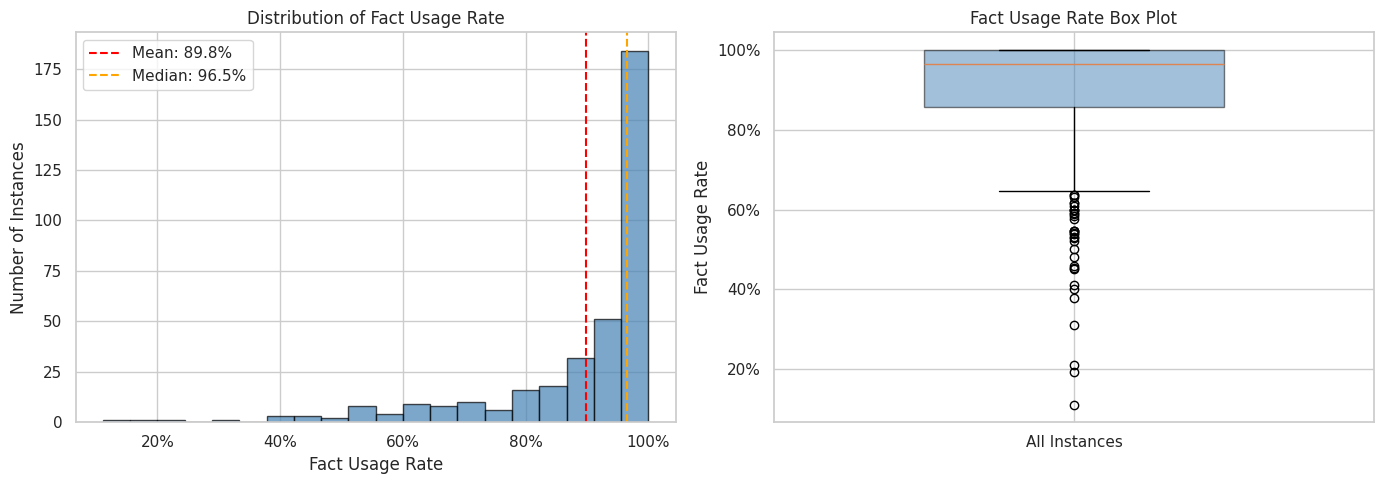

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df["fact_usage_rate"], bins=20, edgecolor="black", alpha=0.7, color="steelblue")
ax.set_xlabel("Fact Usage Rate")
ax.set_ylabel("Number of Instances")
ax.set_title("Distribution of Fact Usage Rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axvline(df["fact_usage_rate"].mean(), color="red", linestyle="--", label=f"Mean: {df['fact_usage_rate'].mean():.1%}")
ax.axvline(df["fact_usage_rate"].median(), color="orange", linestyle="--", label=f"Median: {df['fact_usage_rate'].median():.1%}")
ax.legend()

# Box plot
ax = axes[1]
ax.boxplot(df["fact_usage_rate"], vert=True, widths=0.5,
           patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.5))
ax.set_ylabel("Fact Usage Rate")
ax.set_title("Fact Usage Rate Box Plot")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(["All Instances"])

plt.tight_layout()
plt.show()

## 7. Scatter: Total Facts vs Facts Used

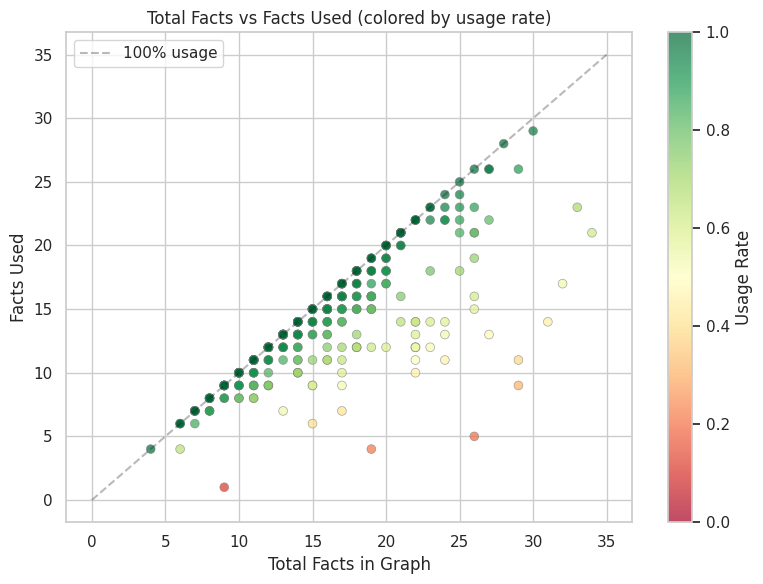

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    df["total_facts"], df["facts_used"],
    c=df["fact_usage_rate"], cmap="RdYlGn", s=40, alpha=0.7,
    edgecolors="gray", linewidths=0.5, vmin=0, vmax=1,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Usage Rate")

# Diagonal line (100% usage)
max_val = max(df["total_facts"].max(), df["facts_used"].max()) + 1
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.3, label="100% usage")

ax.set_xlabel("Total Facts in Graph")
ax.set_ylabel("Facts Used")
ax.set_title("Total Facts vs Facts Used (colored by usage rate)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Stacked Bar: Used / Unused per Instance

Showing every 3-th instance (98 of 292)


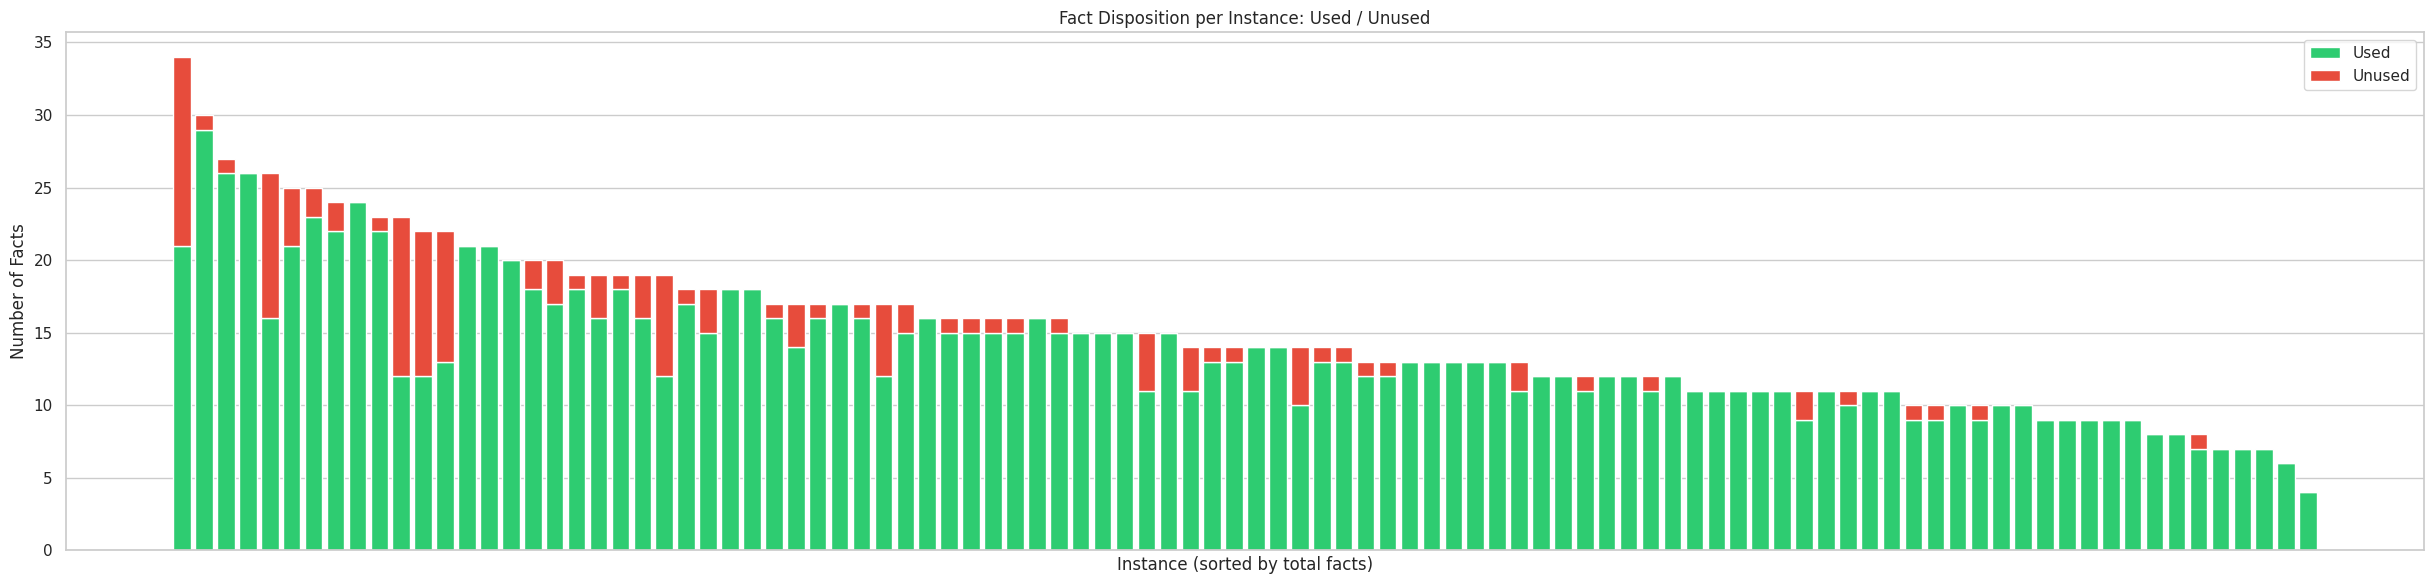

In [44]:
# Sort by total_facts descending for readability
df_bar = df.sort_values("total_facts", ascending=False).reset_index(drop=True)

# Only show up to 80 instances for readability; if more, sample evenly
MAX_BAR = 80
if len(df_bar) > MAX_BAR:
    step = len(df_bar) // MAX_BAR
    df_bar = df_bar.iloc[::step].reset_index(drop=True)
    print(f"Showing every {step}-th instance ({len(df_bar)} of {len(df)})")

fig, ax = plt.subplots(figsize=(max(12, len(df_bar) * 0.25), 6))

x = np.arange(len(df_bar))
w = 0.8

ax.bar(x, df_bar["facts_used"], w, label="Used", color="#2ecc71")
ax.bar(x, df_bar["facts_unused"], w, bottom=df_bar["facts_used"],
       label="Unused", color="#e74c3c")

ax.set_xlabel("Instance (sorted by total facts)")
ax.set_ylabel("Number of Facts")
ax.set_title("Fact Disposition per Instance: Used / Unused")
ax.legend()
ax.set_xticks([])
plt.tight_layout()
plt.show()

## 9. Node Type Breakdown

       node_type  total  used  unused  usage_rate
            fact   5588  5562      26    0.995347
       code_edit   1345   971     374    0.721933
      validation   1113   782     331    0.702606
reproduce_script    414   359      55    0.867150
  issue_analysis    358   347      11    0.969274
        fix_plan    356   343      13    0.963483
         dynamic     14    14       0    1.000000
          static      4     4       0    1.000000


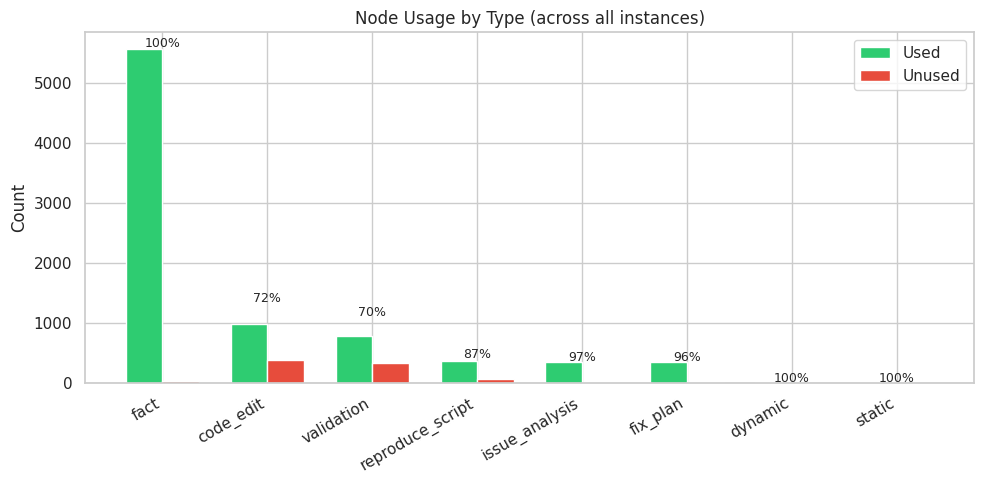

In [57]:
# For each node type, compute the overall usage rate across all instances
node_type_stats: dict[str, dict] = defaultdict(lambda: {"total": 0, "used": 0})

for iid in common_ids:
    nodes = fact_graphs[iid]
    used_ids = set(log_data[iid]["last_usage_summary"].get("used_ids", []))

    for node in nodes:
        nt = node["node_type"]
        node_type_stats[nt]["total"] += 1
        if node["id"] in used_ids:
            node_type_stats[nt]["used"] += 1

nt_rows = []
for nt, s in sorted(node_type_stats.items(), key=lambda x: x[1]["total"], reverse=True):
    nt_rows.append({
        "node_type": nt,
        "total": s["total"],
        "used": s["used"],
        "unused": s["total"] - s["used"],
        "usage_rate": s["used"] / s["total"] if s["total"] > 0 else 0,
    })

df_nt = pd.DataFrame(nt_rows)
print(df_nt.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_nt))
w = 0.35
ax.bar(x - w/2, df_nt["used"], w, label="Used", color="#2ecc71")
ax.bar(x + w/2, df_nt["unused"], w, label="Unused", color="#e74c3c")
ax.set_xticks(x)
ax.set_xticklabels(df_nt["node_type"], rotation=30, ha="right")
ax.set_ylabel("Count")
ax.set_title("Node Usage by Type (across all instances)")
ax.legend()

# Add usage rate labels on top
for i, row in df_nt.iterrows():
    ax.text(i, row["total"] + 1, f"{row['usage_rate']:.0%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Step Efficiency: Steps vs Fact Usage Rate

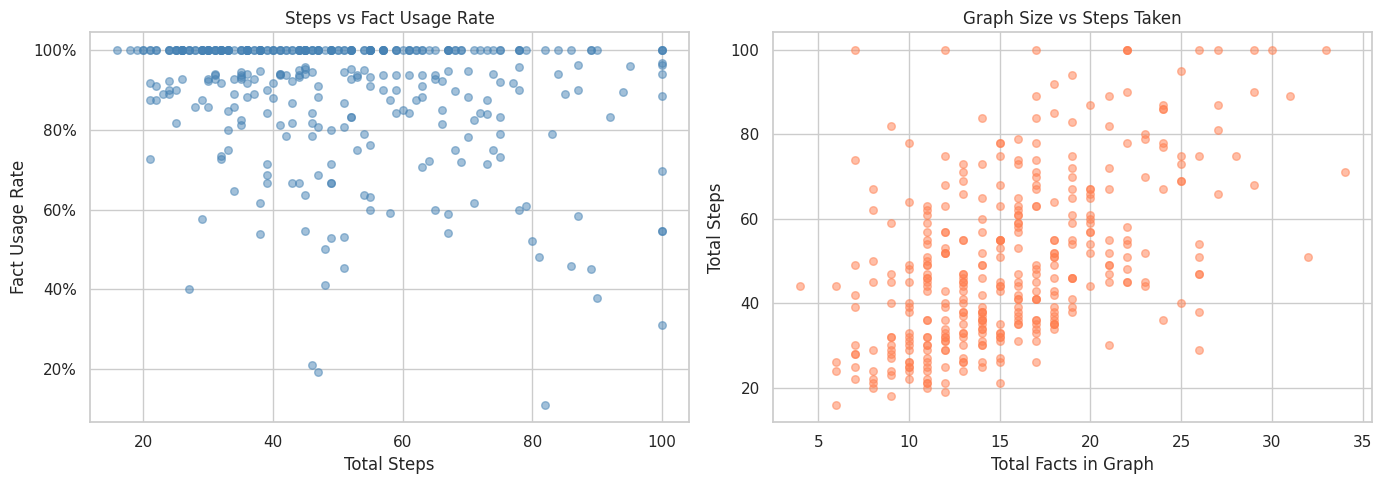

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Steps vs usage rate
ax = axes[0]
ax.scatter(df["total_steps"], df["fact_usage_rate"], alpha=0.5, s=30, color="steelblue")
ax.set_xlabel("Total Steps")
ax.set_ylabel("Fact Usage Rate")
ax.set_title("Steps vs Fact Usage Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Steps vs total_facts
ax = axes[1]
ax.scatter(df["total_facts"], df["total_steps"], alpha=0.5, s=30, color="coral")
ax.set_xlabel("Total Facts in Graph")
ax.set_ylabel("Total Steps")
ax.set_title("Graph Size vs Steps Taken")

plt.tight_layout()
plt.show()

## 11. Unused Facts Detail

In [9]:
# Instances with the most unused facts
df_unused = df[df["facts_unused"] > 0].sort_values("facts_unused", ascending=False)

print(f"Instances with unused facts: {len(df_unused)} / {len(df)}")
print()

if len(df_unused) > 0:
    display_unused = df_unused[
        ["instance_id", "total_facts", "facts_used", "facts_unused",
         "fact_usage_rate", "unused_fact_ids", "total_steps"]
    ].head(30)
    display(display_unused.style.format({"fact_usage_rate": "{:.1%}"}))
else:
    print("All facts were used in every instance.")

Instances with unused facts: 256 / 454



,instance_id,total_facts,facts_used,facts_unused,fact_usage_rate,unused_fact_ids,total_steps
19,getmoto__moto-4951,26,5,21,19.2%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f24', 'f27', 'f29', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']",47
378,python__mypy-14163,29,9,20,31.0%,"['f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f27', 'f29', 'f3', 'f30', 'f4', 'f5', 'f6', 'f9']",100
364,python__mypy-12741,21,1,20,4.8%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f2', 'f20', 'f21', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']",48
301,python__mypy-10389,25,7,18,28.0%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f28', 'f4', 'f7', 'f8', 'f9']",85
339,python__mypy-11317,29,11,18,37.9%,"['f11', 'f13', 'f14', 'f15', 'f18', 'f21', 'f22', 'f24', 'f25', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f36', 'f7', 'f8']",90
331,python__mypy-11213,20,2,18,10.0%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f2', 'f22', 'f23', 'f24', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']",92
391,python__mypy-15050,26,9,17,34.6%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f2', 'f20', 'f21', 'f25', 'f26', 'f8', 'f9']",82
144,getmoto__moto-6075,31,14,17,45.2%,"['f10', 'f11', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f29', 'f31']",89
305,python__mypy-10432,20,4,16,20.0%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f20', 'f21', 'f4', 'f6', 'f7', 'f8', 'f9']",88
420,python__mypy-16053,20,4,16,20.0%,"['f10', 'f11', 'f12', 'f13', 'f14', 'f17', 'f18', 'f19', 'f20', 'f21', 'f23', 'f24', 'f4', 'f7', 'f8', 'f9']",59


## 12. Lowest Usage Instances (Deep Dive)

In [60]:
# Show the 20 instances with the lowest fact usage rate
df_low = df.sort_values("fact_usage_rate", ascending=True).head(20)

display_low = df_low[
    ["instance_id", "total_facts", "facts_used", "facts_unused",
     "fact_usage_rate", "total_steps", "stages_reached"]
]
display(display_low.style.format({"fact_usage_rate": "{:.1%}"}))

,instance_id,total_facts,facts_used,facts_unused,fact_usage_rate,total_steps,stages_reached
135,getmoto__moto-6006,9,1,8,11.1%,82,"exploration, reproduction"
19,getmoto__moto-4951,26,5,21,19.2%,47,"analysis_planning, exploration, finish, implementation_verification, reproduction"
299,python__mypy-10683,19,4,15,21.1%,46,"analysis_planning, exploration, implementation_verification, reproduction"
324,python__mypy-14163,29,9,20,31.0%,100,"analysis_planning, exploration, implementation_verification, reproduction"
309,python__mypy-11317,29,11,18,37.9%,90,"analysis_planning, exploration, implementation_verification, reproduction"
333,python__mypy-15208,15,6,9,40.0%,27,"analysis_planning, exploration, implementation_verification, reproduction"
349,python__mypy-17028,17,7,10,41.2%,48,"analysis_planning, exploration, finish, implementation_verification, reproduction"
144,getmoto__moto-6075,31,14,17,45.2%,89,"analysis_planning, exploration, implementation_verification, reproduction"
139,getmoto__moto-6028,22,10,12,45.5%,51,"analysis_planning, exploration, implementation_verification, reproduction"
341,python__mypy-15846,24,11,13,45.8%,86,"analysis_planning, exploration, implementation_verification, reproduction"


## 13. Highest Usage Instances

In [ ]:
# Show the 20 instances with the highest fact usage rate
df_high = df.sort_values("fact_usage_rate", ascending=False).head(20)

display_high = df_high[
    ["instance_id", "total_facts", "facts_used", "facts_unused",
     "fact_usage_rate", "total_steps", "stages_reached"]
]
display(display_high.style.format({"fact_usage_rate": "{:.1%}"}))

## 14. Usage Rate by Graph Complexity Bucket

In [ ]:
# Bucket instances by total_facts and compare usage rates
bins = [0, 10, 15, 20, 30, 50, 200]
labels = ["1-10", "11-15", "16-20", "21-30", "31-50", "51+"]
df["fact_bucket"] = pd.cut(df["total_facts"], bins=bins, labels=labels, right=True)

bucket_stats = df.groupby("fact_bucket", observed=False).agg(
    count=("instance_id", "count"),
    mean_usage_rate=("fact_usage_rate", "mean"),
    median_usage_rate=("fact_usage_rate", "median"),
    mean_steps=("total_steps", "mean"),
    mean_unused=("facts_unused", "mean"),
).reset_index()

print(bucket_stats.to_string(index=False))

# Bar chart of mean usage rate by bucket
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bucket_stats))
bars = ax.bar(x, bucket_stats["mean_usage_rate"], color="steelblue", edgecolor="black", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(bucket_stats["fact_bucket"])
ax.set_xlabel("Total Facts (bucket)")
ax.set_ylabel("Mean Fact Usage Rate")
ax.set_title("Mean Fact Usage Rate by Graph Complexity")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Label counts on bars
for i, (bar, count) in enumerate(zip(bars, bucket_stats["count"])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"n={count}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()